# Лабораторная работа 3

## Сингулярное разложение и его приложения

Напомним, что сингулярным разложением (SVD, Singular value decomposition) матрицы $A$ размера $m\times n$ называется представление

$$A = U\Sigma V^T,$$

где $U$ — ортогональная матрица размера $m\times m$, $V$ — ортогональная матрица размера $n\times n$, $\Sigma = \mathrm{diag}(\sigma_1,\sigma_2,\sigma_3,\ldots)$ — диагональная матрица размера $m\times n$, в которой $\sigma_1\geqslant\sigma_2\geqslant\ldots\geqslant0$.

На самом деле требование, чтобы матрицы $U$ и $V$ были квадратными, избыточно. *Усечённым сингулярным разложением* мы будем называть разложение

$$A = U\Sigma V^T,$$

где $U$ и $V$ — матрицы с ортонормированными столбцами размеров $m\times k$ и $n \times k$ соответственно, $\Sigma$ — диагональная матрица размера $k\times k$, где $k = \min(m,n)$. Далее мы будем работать исключительно с усечённым разложением.

### Сжатие данных с помощью SVD = построение низкорангового приближения

Введём *норму Фробениуса* матрицы как

$$||A||_{frob} = \sqrt{\mathrm{tr}{A^TA}} = \sqrt{\sum\limits_{i,j}a^2_{i,j}}$$

Иными словами, это обычное евклидово расстояние на пространстве, которое получается, если все матрицы вытянуть в длинные векторы.

Зададимся вопросом: как найти матрицу $A_{r}$ ранга $r$, наименее отличающуюся от $A$ по норме Фробениуса (то есть для которой норма разности $||A - A_{r}||_{frob}$ минимальна). Оказывается, это можно сделать с помощью сингулярного разложения:

**Теорема.** Пусть $\Sigma_{r}$ — это матрица, полученная из $\Sigma$ заменой диагональных элементов $\sigma_{i}$ ($i > r$) нулями, тогда $A_{r} = U\Sigma_{r}V^T$.

Это можно переписать и в более экономичном виде. Если

$$A = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1k}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mk}
\end{pmatrix}}_{=U}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \sigma_{2} & \\
 & & \ddots
\end{pmatrix}}
}_{=\Sigma}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1k} & \ldots & v_{nk}
\end{pmatrix}}_{=V^T}$$

то

$$A_{r} = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1r}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mr}
\end{pmatrix}}_{=U_r}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \ddots & \\
 & & \sigma_{r}
\end{pmatrix}}
}_{=\Sigma_r}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1r} & \ldots & v_{nr}
\end{pmatrix}}_{=V^T_r}$$

При этом

$$||A - A_{r}||_{frob} = \sqrt{\sum\limits_{i\geqslant r+1} \sigma_{i}^2}$$

Если сингулярные значения матрицы падают достаточно быстро (а в реальных задачах часто бывает именно так), то норма разности будет малой при сравнительно небольшом значении $r$.

На хранение исходной матрицы нам требовалось $m\times n$ памяти. Теперь же, если мы будем хранить отдельно $U_r$, $V_r$ и диагональные элементы $\Sigma_r$, затраты памяти составят $mr + nr + r = r(m + n + 1)$.

**Разложение на компоненты ранга 1**

Обозначим через $u_1,\ldots, u_k$ столбцы матрицы $U$, а через $v_1, \ldots, v_k$ столбцы матрицы $V$. Тогда имеет место равенство

$$A = u_1\sigma_{1}v_1^T + u_2\sigma_{2}v_2^T + u_3\sigma_{3}v_3^T + \ldots$$

Матрицу $u_k\sigma_{k}v_k^T = \sigma_{k}u_kv_k^T$ мы будем называть $k$-й компонентой ранга 1 матрицы $A$. Отметим, что слагаемые в этой сумме ортогональны относительно скалярного произведения $(X, Y) = \mathrm{tr}(X^TY)$ (порождающего норму Фробениуса).

Как нетрудно заметить,

$$A_{r} = \sigma_{1}u_1v_1^T + \sigma_{2}u_2v_2^T + \ldots + \sigma_{r}u_rv_r^T$$

**Технические детали (SVD в Питоне)**

Есть несколько способов сделать в Питоне сингулярное разложение; мы пока предлагаем Вам использовать

`import scipy.linalg as sla`

`U, S, Vt = sla.svd(X, full_matrices=False)`

Для ознакомления с особенностями этой функции рекомендуем обратиться к [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.svd.html) (в частности, обратите внимание на то, какие именно объекты она возвращает).

### Правила оформления графиков

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

Ещё одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- для точек из разных выборок, необходимо использовать разные цвета;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- размер графика должен быть таким, чтобы по нему несложно было сделать необходимые выводы о данных;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах).

Помните, что проверяющий имеет право снизить оценку за неопрятные графики.

### Оценивание

Обратите внимание, что в каждом разделе есть задания на написания кода и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если Вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то в подавляющем большинстве случаев баллы за такое выставлены не будут.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-03-linregr-Username.ipynb, где Username — Ваша фамилия.

### Задание 1. Сжатие данных с помощью SVD

Загрузите выложенную на странице курса фотографию.

In [ ]:
import numpy as np
from skimage.io import imread

img = imread(r'chain_small.jpg')
img = img.mean(axis=2) # это матрица из интенсивностей серого цвета; её уже можно подвергать SVD

Нарисуйте картинку:

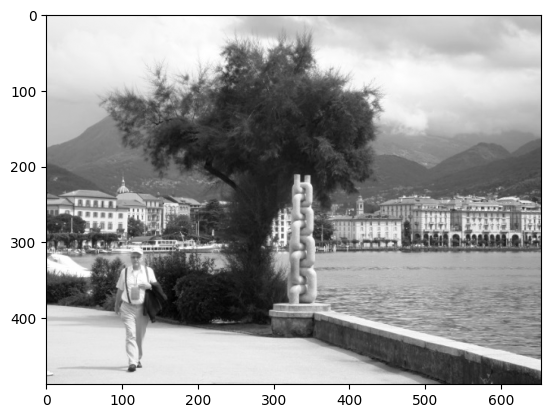

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

imgplot = plt.imshow(img, cmap='gray')

Постройте сингулярное разложение этой матрицы.

In [ ]:
from numpy.linalg import svd

U, S, VT = svd(img, full_matrices=False)

**1. [0.1 балла]** Нарисуйте график диагональных элементов матрицы $\Sigma$:

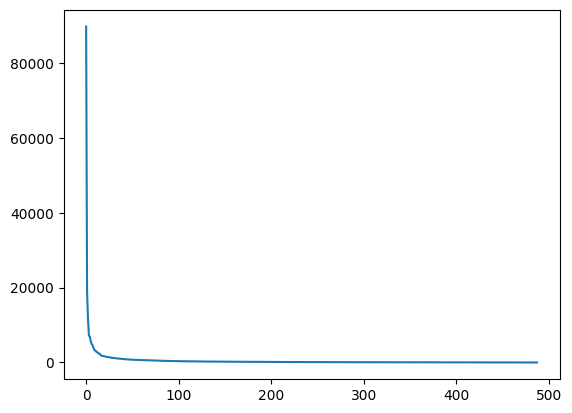

In [ ]:
diag = S
plt.plot(diag)

Кажется, что они убывают достаточно быстро и есть надежда, что первые несколько компонент дадут картинку, близкую к исходной.

**Важно:** при визуализации различных компонент в этом задании используйте только матричные операции. В частности, избегайте циклов, функций `map` и `reduce`, а также специальных функций, находящих суммы компонент.

**2. [0.1 балла]** Визуализуйте первую компоненту ранга 1. Ожидали ли Вы увидеть именно это? Поясните.

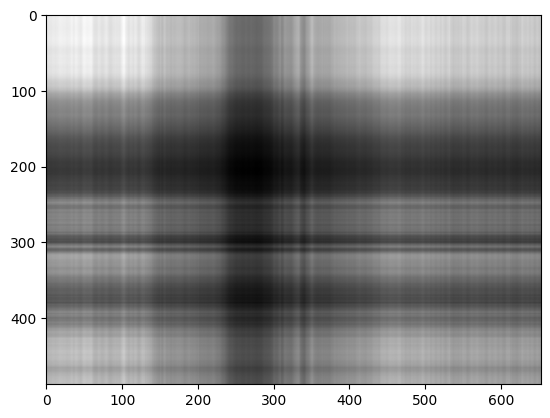

In [ ]:
V = VT.T
n = U[:, 0].size
m = V[:, 0].size
u1 = U[:, 0].reshape(n, 1)
v1 = V[:, 0].reshape(m, 1)
vt1 = v1.T
A1 = S[0] * np.dot(u1, vt1)
imgplot_1 = plt.imshow(A1, cmap='gray')

**Пояснение:** Визуализация первой компоненты ранга 1 - это размытый силуэт исходного изображения.

Матрица А имеет вид:
$$A = \sigma_{1}u_1v_1^T + \sigma_{2}u_2v_2^T + \ldots$$
где $\sigma_1\geqslant\sigma_2\geqslant\ldots\geqslant0$.

Получается, чем меньше номер компоненты, тем больший вклад в разложение А она имеет, поэтому первая компонента передаёт основную информацию, но без деталей (например, без резких границ). Для точного восстановления изображения нужно учитывать больше компонент.
Это полностью соответствует ожиданиям.

**3. [0.5 балла]** Визуализуйте суммы компонент ранга 1 с первой по двадцатую, с первой по пятидесятую, с двадцатой по сотую, с двадцатой по последнюю. Сделайте выводы.

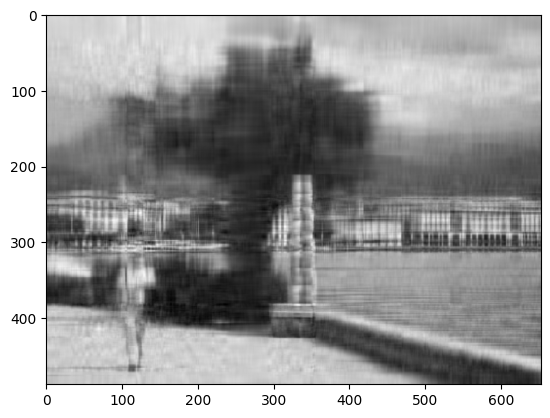

In [ ]:
u1_20 = U[: , : 20]
v1_20 = V[: , : 20]
vt1_20 = np.dot(np.diag(S[: 20]), v1_20.T)
A1_20 = np.dot(u1_20, vt1_20)
imgplot_1_20 = plt.imshow(A1_20, cmap='gray')

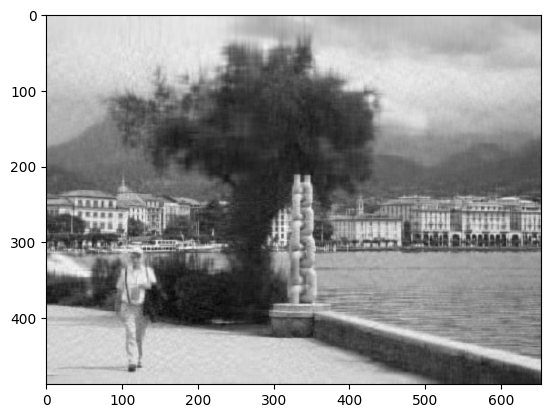

In [ ]:
u1_50 = U[: , : 50]
v1_50 = V[: , : 50]
vt1_50 = np.dot(np.diag(S[: 50]), v1_50.T)
A1_50 = np.dot(u1_50, vt1_50)
imgplot_1_50 = plt.imshow(A1_50, cmap='gray')

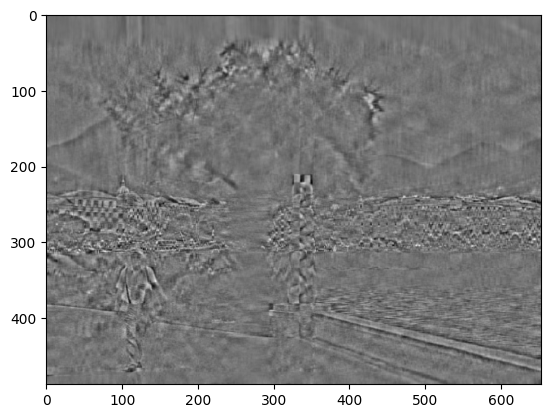

In [ ]:
u20_100 = U[: , 20 : 100]
v20_100 = V[: , 20 : 100]
vt20_100 = np.dot(np.diag(S[20 : 100]), v20_100.T)
A20_100 = np.dot(u20_100, vt20_100)
imgplot_20_100 = plt.imshow(A20_100, cmap='gray')

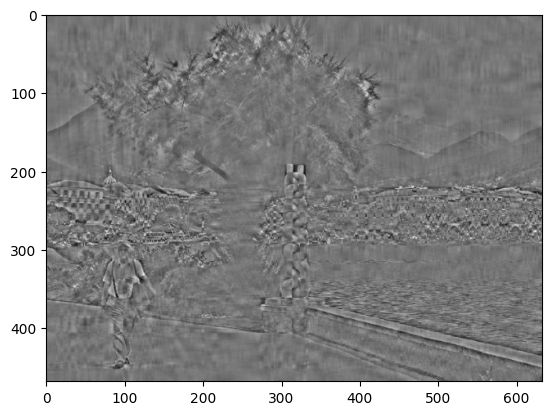

In [ ]:
u20_ = U[20 : , 20 :]
v20_ = V[20 : , 20 :]
vt20_ = np.dot(np.diag(S[20 :]), v20_.T)
A20_ = np.dot(u20_, vt20_)
imgplot_20_ = plt.imshow(A20_, cmap='gray')

**Выводы:**

Сумма компонент с 1 по 20: Дает грубое приближение исходного изображения, сохраняя только самые важные особенности. Мелкие детали отсутствуют.

Сумма компонент с 1 по 50: Улучшает качество по сравнению с предыдущим случаем, добавляя больше деталей, но всё ещё выглядит размыто.

Сумма компонент с 20 по 100: Теряются основные контуры(так как первые 19 компонент отсутствуют).

Сумма компонент с 20 по последнюю: Изображение с потерянным контрастом и основными структурами(их дают первые компоненты), но с сохранением мелких деталей.

Таким образом, первые компоненты несут основную информацию о структуре изображения, а последующие добавляют детализацию.

**4. [0.35 балла]** Как Вам кажется, какие компоненты нужно взять для достаточно хорошего восстановления исходного изображения? Аргументируйте свой ответ. Не забудьте визуализировать сумму выбранных компонент.

*Комментарий: для получения полного балла за это задания постарайтесь привести более убедительный аргумент, нежели Ваши субъективные впечатления от сравнения полученного изображения с исходным.*

Исходя из выводов, сделанных в задании 3, для хорошего восстановления исходного изображения нужно взять хотя бы 50 первых компонент (они несут основную информацию о структуре изображения). Остальные компоненты нужны для более точной детализации.

Ставя перед собой задачу минимизации памяти, оптимальтно рассмотреть сумму первых 100 компонент.

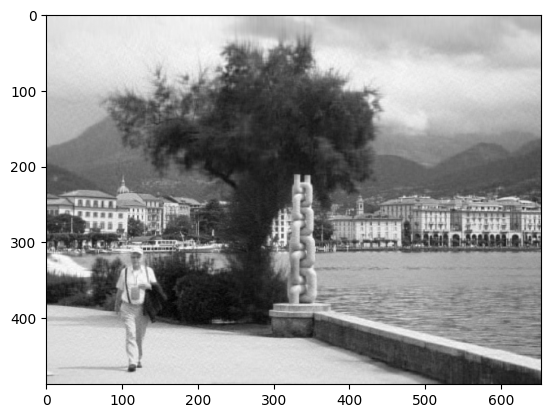

In [ ]:
u1_100 = U[: , : 100]
v1_100 = V[: , : 100]
vt1_100 = np.dot(np.diag(S[: 100]), v1_100.T)
A1_100 = np.dot(u1_100, vt1_100)
imgplot_1_100 = plt.imshow(A1_100, cmap='gray')

**5. [0.15 балла]** Во сколько раз меньше памяти (теоретически) потребуется для хранения нового изображения по сравнению с исходным?

In [ ]:
print('Хранение исходной матрицы:', m * n)
r = min(n, m) # тут получаем, что r = n
print('Хранение всего сингулярного разложения:', m*r + n*r + r)
print('Хранение суммы первых 100 компонент сингулярного разложения:', m*100 + n*100 + 100)

Хранение исходной матрицы: 318664
Хранение всего сингулярного разложения: 557296
Хранение суммы первых 100 компонент сингулярного разложения: 114200


╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ\
На хранение исходной матрицы нам требовалось $m\times n = 318664$ памяти. Если храним сингулярное разложение, затраты памяти составляют $m\times n + n\times n + n = n\times(m + n + 1) = 557296$. А для хранения суммы первых 100 компонент сингулярного разложения потребуется всего $m\times 100 + n\times 100 + 100 = 100\times(m + n + 1) = 114200$ памяти.\
Это в $2.79$ раз меньше, чем хранение исходной матрицы, и в $4.88$ раз меньше, чем хранение всего сингулярного разложения.

**6. [0.25 балла]** Подсчитайте, сколько в действительности места в памяти компьютера занимают исходная матрица и компоненты её сингулярного разложения. Согласуется ли этот результат с ответом предыдущего пункта? Сделайте выводы.

In [ ]:
memory_A = img.nbytes
memory_Asvd = U.nbytes + S.nbytes + VT.nbytes
memory_Asvd1_100 = u1_100.nbytes + S[: 100].nbytes + vt1_100.nbytes
print('Хранение исходной матрицы:', memory_A)
print('Хранение всего сингулярного разложения:', memory_Asvd)
print('Хранение суммы первых 100 компонент сингулярного разложения:', memory_Asvd1_100)
print(f'Получаем, что хранение суммы первых 100 компонент сингулярного разложения требует в {memory_A/memory_Asvd1_100:.2f} раз меньше памяти, чем хранение исходной матрицы,\nи в {memory_Asvd/memory_Asvd1_100:.2f} раз меньше памяти, чем хранение всего сингулярного разложения.')

Хранение исходной матрицы: 2549312
Хранение всего сингулярного разложения: 4458368
Хранение суммы первых 100 компонент сингулярного разложения: 913600
Получаем, что хранение суммы первых 100 компонент сингулярного разложения требует в 2.79 раз меньше памяти, чем хранение исходной матрицы,
и в 4.88 раз меньше памяти, чем хранение всего сингулярного разложения.


**Вывод:** Теоретический и практический результат совпадают, поэтому можно сделать вывод, что данная оптимизация обеспечивает предсказуемое сжатие данных.

### Задание 2. Геометрия SVD. Визуализация данных с помощью SVD

**Геометрический смысл SVD**

Допустим, что у нас есть выборка $x_1,\ldots,x_m\in\mathbb{R}^n$. Запишем её в матрицу объекты-признаки

$$X = \begin{pmatrix}
x_{11} & \ldots & x_{1n}\\
\vdots & & \vdots\\
x_{m1} & \ldots & x_{mn}
\end{pmatrix}$$

(строки — объекты, столбцы — признаки) и сделаем SVD-разложение: $X = U\Sigma V^T$. Его можно интерпретировать следующим образом:

$$X = U\Sigma\cdot V^T,$$

где $U\Sigma$ — это матрица объекты-признаки для тех же объектов, но в новых признаках, полученных из исходных с помощью линейного преобразования $V$ (напоминаем, что умножение на матрицу справа соответствует преобразованию столбцов). Попробуем понять, чем замечательны эти признаки.

Рассмотрим матрицу $X^TX = V\Sigma^2V^T$. Легко видеть, что это матрица Грама системы столбцов матрицы $X$; иными словами, в ней записаны скалярные произведения векторов различных признаков. Из лекций вы знаете, что $\sigma_1^2$, квадрат первого сингулярного числа, это наибольшее собственное значение матрицы $X^TX$, а $v_1$, первый столбец матрицы $V$, — это соответствующий собственный вектор. Можно показать, что

$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}\left(|Xw|\right).$$

Попробуем осознать физический смысл этой штуки. Напомним, что строки матрицы $X$ — это координаты объектов $x_1,\ldots,x_m$ в пространстве признаков. Произведение $Xw$ — это вектор из значений на тех же самых объектах некоторого нового признака, являющегося линейной комбинацией исходных с коэффициентами $w_1,\ldots,w_n$:

$$Xw = w_1\begin{pmatrix} x_{11}\\ \ldots \\ x_{m1}
\end{pmatrix} + w_2\begin{pmatrix} x_{12}\\ \ldots \\ x_{m2}
\end{pmatrix} + \ldots + w_n\begin{pmatrix} x_{1n}\\ \ldots \\ x_{mn}
\end{pmatrix}$$

Соответственно, $|Xw|^2$ — это квадрат длины вектора, составленного из значений нового признака.

Таким образом, первому сингулярному значению $\sigma_1$ отвечает такой признак, у которого сумма квадратов значений максимальна, то есть признак, принимающий, условно говоря, самые большие значения.

Резюмируя, мы можем сказать, что сингулярное разложение делает следующее:
- находит новый признак (новое направление) вдоль которого "дисперсия"$^1$ максимальна;
- в ортогональной ему плоскости находит признак, вдоль которого "дисперсия" максимальна;
- и так далее.

---
$^1$ настоящая выборочная дисперсия с точностью до числового множителя была бы равна $|Xw - \overline{Xw}|^2$, где $\overline{Xw} = \frac1m\sum_{i=1}^m(Xw)_i$ — среднее значения признака.

**1. [1.25 балла]** Пусть $\sigma_1$ — старшее сингулярное число матрицы $X$ размера $m \times n$. Покажите, что верна цепочка равенств
$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}~|Xw| = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|.$$

**Подсказки:**
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|}$ выразите вектор $w$ как $\alpha\cdot v$, где $|v|=1$, и рассмотрите описанное выражение
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|w| = 1}~|Xw|$ представьте $w$ в виде линейной комбинации ортонормированного базиса, состоящего из собственных векторов оператора $X^TX$, и внимательно посмотрите на произведение $wX^TXw$
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|$ разложите матрицу $X$ в SVD-разложение, а векторы $u$ и $w$ представьте в виде линейной комбинации векторов, являющихся столбцами матриц $U$ и $V$.

**Решение:**\
$1)$ Пусть $w\in\mathbb{R}^n$. Представим  $w$ как $w = \alpha\cdot v$, где $|v|=1$, $(\alpha\ = |w|$, $v = \frac{w}{|w|})$.\
Тогда  $\frac{|Xw|}{|w|} = \frac{|X(\alpha\cdot v)|}{|\alpha\cdot v|} = \frac{|\alpha Xv)|}{|\alpha|} = |Xv|$.\
Теперь найдем $\mathrm{max}_{w}\frac{|Xw|}{|w|}$, то есть $\mathrm{max}_{|v| = 1}|Xv|$.\
$|Xv| = |U\Sigma V^Tv| = |\Sigma V^Tv|$ (так как $U$ ортогональна).\
Обозначим $y = V^Tv$. Заметим, что $|y| = |v| = 1$, так как $V$ ортогональна.\
Тогда $|\Sigma y|^2 = \sum_{i=1}^r\sigma_{i}^2y_{i}^2\leqslant\sigma_1^2\sum_{i=1}^ry_{i}^2 = \sigma_1^2|y|^2 = \sigma_1^2$, где $r = rank(X)$.\
Равенство достигается, когда $y = e_1 = (1,0,\ldots,0)^T$. Тогда $|\Sigma y|=|\Sigma e_1| = \sigma_1$.\
Такой $y$ получается при $v = v_1$ (первый столбец $V$): $V^Tv_1 = e_1\Rightarrow \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|v| = 1}|Xv| = |Xv_1| = |U\Sigma V^Tv_1| = |\Sigma V^Tv_1| = |\Sigma e_1| = \sigma_1$ что и требовалось доказать.\
$2)$ Представим вектор $w$ единичной длины как линейную комбинацию столбцов $V$, (которые являются собственными векторами $X^TX$): $w = \sum_{i=1}^n\alpha_{i}v_{i}$, $\sum_{i=1}^n\alpha_{i}^2 = 1$.\
$|Xw|^2 = w^TX^TXw = \sum_{i=1}^r\sigma_{i}^2\alpha_{i}^2$ (так как $v_{i}$ - собственные векторы $X^TX$ с собственными значениями $\sigma_{i}^2$) $\leqslant\sigma_1^2\sum_{i=1}^r\alpha_{i}^2\leqslant\sigma_1^2$, где $r = rank(X)$.\
$\mathrm{max}_{|w| = 1}|Xw|$ достигается при $w = v_1$ (первый столбец $V$).\
$|Xv_1| = |U\Sigma V^Tv_1| = |\Sigma V^Tv_1| = |\Sigma e_1| = \sigma_1$, что и требовалось доказать.\
$3)$ Пусть $X = U\Sigma V^T$. Представим $u$ и $v$ как линейные комбинации столбцов $U$ и $V$ соответственно: $u = \sum_{i=1}^m\alpha_{i}u_{i}$, $v = \sum_{j=1}^n\beta_{j}v_{j}$, при этом $\sum_{i=1}^m\alpha_{i}^2 = 1$, $\sum_{j=1}^n\beta_{j}^2 = 1$.\
Тогда $u^TXv = u^T(U\Sigma V^T)v = (U^Tu)^T\Sigma(V^Tv) = \sum_{i=1}^r\sigma_{i}\alpha_{i}\beta_{i}$, где $r = rank(X)$.\
$|u^TXv| = \sum_{i=1}^r\sigma_{i}|\alpha_{i}\beta_{i}|\leqslant\sigma_1\sum_{i=1}^r|\alpha_{i}\beta_{i}|\leqslant\sigma_1$.\
Равенство достигается при $u = u_1$ и $v = v_1$. Тогда $|u^TXv| = |u_1^TXv_1| = |e_1^T\Sigma e_1| = \sigma_1$ что и требовалось доказать.

**2. [0.75 балла]** Рассмотрим матрицу $A = (a_{ij})$ размера $n \times n$, такую что $a_{ij} = \sin i \cdot \cos j$, причём нумерация ведётся с нуля. Найдите $r = \text{rk}A$ (можете считать, что $n > 1$), а также разложение (Compact SVD) $A=U \Sigma V^T$, где $U$ и $V$ — матрицы с ортонормированными столбцами размера $n\times r$, а $\Sigma = \mathrm{diag}(\sigma_1,\ldots,\sigma_r)$ — диагональная матрица размера $r\times r$, в которой $\sigma_1\geqslant\ldots\geqslant\sigma_r > 0$.

**Решение:**\
Заметим, что $A = a1\cdot a2^T$, где $a1 = \begin{pmatrix} sin(0)\\sin(1)\\ \ldots \\ sin(n-1)\end{pmatrix}$, $a2 = \begin{pmatrix} cos(0)\\cos(1)\\ \ldots \\ cos(n-1)\end{pmatrix}$.\
Матрица, представленная как внешнее произведение двух ненулевых векторов, имеет ранг $1\Rightarrow \text{rk}A = 1$.\
Теперь найдем Compact SVD разложение $A$.\
$\text{rk}A = 1 \Rightarrow$ SVD разложение $A$ имеет вид: $A = \sigma_1u_1v_1^T$.\
$\sigma_1 = ||A|| = ||a_1||\cdot||a_2|| = \sqrt{\sum_{k=0}^{n-1}sin^2k}\cdot\sqrt{\sum_{k=0}^{n-1}cos^2k}$.\
$||a_1|| = \sum_{k=0}^{n-1}sin^2k = \frac{n}{2} - \frac{sin(n)cos(n-1)}{2sin(1)}$.\
$||a_2|| = \sum_{k=0}^{n-1}cos^2k = \frac{n}{2} + \frac{sin(n)cos(n-1)}{2sin(1)}$.\
Итак, Compact SVD разложение $A = \sigma_1u_1v_1^T$, где $u_1 = \frac{a_1}{||a_1||}$, $v_1^T = (\frac{a_2}{||a_2||})^T$, $\sigma_1 = ||a_1||\cdot||a_2||$.

**3. [0.5 балла]** Рассмотрим полное сингулярное разложение $A = U \Sigma V^T$ для матрицы размера $m \times n$, такой что $\text{rk}A=r$. Определим также линейное отображение $\mathcal{A} \colon \mathbb{R}^n \to \mathbb{R}^m$, которое действует умножением на матрицу $A$. Покажите, что $\text{Im}\mathcal{A} = \langle u_1, \ldots, u_r \rangle$, а $\text{Ker}\mathcal{A} = \langle v_{r+1}, \ldots, v_n \rangle$.

**Решение:**\
$\text{Im}\mathcal{A} = \{Ax | x \in\mathbb{R}^n\} = \{U \Sigma V^Tx | x \in\mathbb{R}^n\}$. Пусть $y = V^Tx$, тогда $\text{Im}\mathcal{A} = \{U \Sigma y | y \in\mathbb{R}^n\} = \{U(\sigma_1y_1,\ldots,\sigma_ry_r,0,\ldots,0)^T | y \in\mathbb{R}^n\} = \{\sum_{i=1}^r(\sigma_{i}y_{i})u_{i}| y_i \in\mathbb{R}\}$. Таким образом, $\text{Im}\mathcal{A} = \langle u_1, \ldots, u_r \rangle$.

$\text{Ker}\mathcal{A} = \{x \in\mathbb{R}^n| Ax = 0\} = \{x \in\mathbb{R}^n| U \Sigma V^Tx = 0\}$. Умножим слева на $U^T$ (так как $U$ ортогональна): $\{x \in\mathbb{R}^n| \Sigma V^Tx = 0\}$. Пусть $z = V^Tx$, тогда $\text{Ker}\mathcal{A} = \{Vz | \Sigma z = 0\}$. Условие $\Sigma z = 0$ означает: $\sigma_{i}z_{i} = 0$ для $i = 1,\ldots,r \Rightarrow z_{i} = 0$ при $i\leqslant r$. Тогда $x = Vz = \sum_{i=r+1}^nz_{i}v_{i} \Rightarrow \text{Ker}\mathcal{A} = \langle v_{r+1}, \ldots, v_n \rangle$.

**4. [0.75 балла]** Рассмотрим матрицу $A$ размера $m \times n$, такую что $m \geqslant n$ и столбцы $A$ линейно независимы. Найдите матрицу $\Sigma$ из полного сингулярного разложения для матрицы $P = A(A^T A)^{-1} A^T$.

**Решение:**\
$A = U\Sigma V^T$\
$P = A(A^TA)^{-1}A^T = U\Sigma V^T(V\Sigma^TU^TU\Sigma V^T)^{-1}V\Sigma^TU^T = UΣV^T(V\Sigma^2V^T)^{-1}V\Sigma^TU^T = U\Sigma V^TV\Sigma^{-2}V^TV\Sigma^TU^T = U\Sigma\Sigma^{-2}\Sigma^T U^T = UU^T$\
Таким образом, сингулярное разложение для $P$: $P = UIU^T$, где $I$ - единичная матрица $m\times m$. Матрица $\Sigma$ из полного сингулярного разложения для матрицы $P$ имеет вид: $\Sigma = diag(1,\ldots, 1, 0,\ldots, 0)$, где ровно $n$ единиц и $m-n$ нулей.

**Визуализация данных с помощью SVD**

Выше мы обсудили, что первые из "новых" признаков — это признаки, значения которых, скажем так, наиболее разнообразны. Зачастую (хотя и не всегда) именно они несут в себе наиболее важные черты датасета. И если взять два-три первых, то датасет можно нарисовать и посмотреть на него — и, возможно, обнаружить какую-то структуру.

С помощью функции `dsklearn.datasets.load_digits()` загрузите датасет рукописных цифр [MNIST](http://yann.lecun.com/exdb/mnist/). В нём есть несколько атрибутов; вам сейчас будут нужны `digits.data` (`np.array`, строки которого — это вытянутые в одну строку значения пикселей) и `digits.target` (в них записаны соответствующие цифры).

0


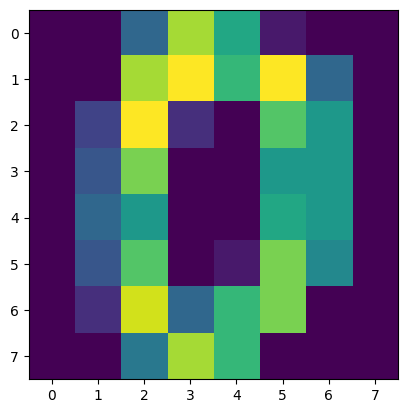

In [ ]:
from sklearn import datasets

digits = datasets.load_digits()

print(digits.target[0])

plt.imshow(digits.data[0].reshape((8,8)))

**5. [0.1 балла]** Примените к матрице `digits.data` сингулярное разложение.

In [ ]:
U, S, VT = svd(digits.data, full_matrices=False)

**6. [0.65 балла]** Визуализируйте данные, спроецировав их на такую плоскость, чтобы координаты точек соответствовали первым двум новым признакам. Не забудьте покрасить точки, отвечающие различным цифрам, в разные цвета (если Вы любите красивые визуализации, разберитесь, как вместо точек рисовать маленькие цифры).

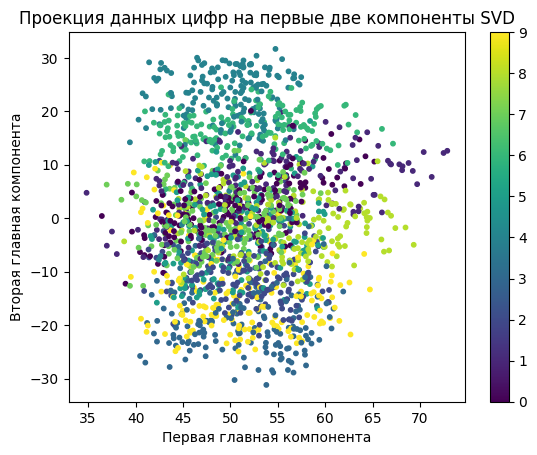

In [ ]:
y = digits.target
S = np.diag(S)
sign = np.dot(U, S)[:, : 2]
result = plt.scatter(sign[:, 0], sign[:, 1], c=y, s=10)
cbar = plt.colorbar(result, ticks=range(10))
plt.title('Проекция данных цифр на первые две компоненты SVD')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

**7. [0.25 балла]** Теперь вычтите из каждого признака его среднее значение, снова сделайте SVD и нарисуйте разноцветные точки.

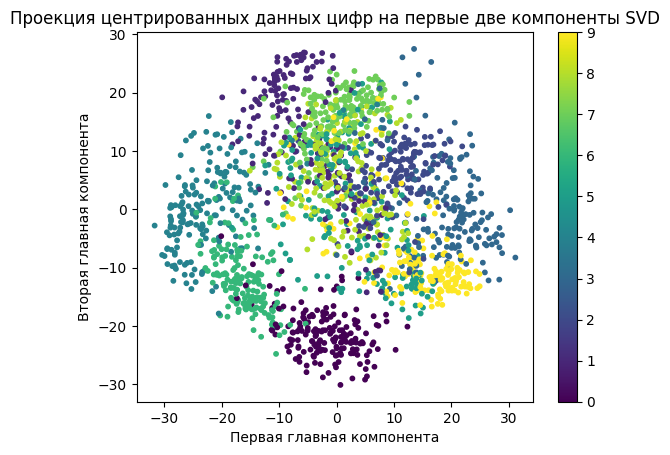

In [ ]:
X = digits.data
y = digits.target
X_new = X - np.mean(X, axis=0)
U, S, VT = svd(X_new, full_matrices=False)
S = np.diag(S)
sign = np.dot(U, S)[:, : 2]
result = plt.scatter(sign[:, 0], sign[:, 1], c=y, s=10)
cbar = plt.colorbar(result, ticks=range(10))
plt.title('Проекция центрированных данных цифр на первые две компоненты SVD')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.show()

**8. [0.25 балла]** Сравните выполненные Вами в двух предыдущих пунктах визуализации. Чем последняя выгодно отличается от первой?

Без центрирования первые компоненты отражают направления максимальной амплитуды (суммы квадратов значений) данных. Компоненты могут быть смещены из-за доминирования одного признака.\
С центрированием компоненты соответствуют направлениям максимальной дисперсии(разброса данных относительно среднего). Компоненты показывают относительные вариации данных.\
Центрирование дает более корректные и интерпретируемые результаты для анализа данных, помогает упростить математические вычисления, улучшает стабильность численных расчетов, предотвращая переполнение или потерю значимости.



### Задание 3. Когда SVD не сработает

**Disclaimer**

Цель этого задания — познакомить Вас не только с геометрическим смыслом сингулярного разложения, но и перекинуть очередной мостик между линейной алгеброй и анализом данных. К сожалению, на том берегу Вас встретят разные пока неизведанные понятия; мы постараемся по возможности дать какие-то определения, но, конечно, нет никакой возможности изложить на этих страницах полный курс теории вероятностей. Поэтому какие-то вещи останутся недосказанными или необоснованными; если Вам будет интересно, не стесняйтесь читать соответствующую литературу или хотя бы Википедию, а если нет, то мы надеемся, что хотя бы наглядное представление у Вас сформируется. В любом случае, нам хотелось бы, чтобы воспоминания об этом всколыхнулись в ваших головах, когда Вы будете это всё изучать в курсе по теории вероятностей.

Но начнём мы с того, что обсудим ситуацию, в которой SVD работает лучше всего: а именно, со случая, когда данные распределены нормально.

**Что такое плотность вероятности**

В дальнейшем Вам достаточно часто придётся сталкиваться со *случайными величинами*. Мы не будем сейчас пытаться строго определить, что это такое (для этого у вас будет целый курс по теории вероятностей), а остановимся только на одном его аспекте.

Если случайная величина $X$ принимает лишь конечное (или счётное) число значений $x_1,x_2,\ldots$, то чтобы задать её, достаточно описать, с какой вероятностью $X$ равна $x_i$:

$$p_i = P(X = x_i)$$

таким образом, чтобы $\sum_ip_i = 1$. Если же $X$ принимает значения на каком-либо отрезке или на всей числовой прямой, то так уже не получится: в этом случае вероятность того, что $X$ равна какому-то конкретному $x_0$, обычно равна нулю. Как правило, заменой вероятностей $p_i$ служит *функция плотности распределения* $p(x)$. Смысл её таков:

$$P(\alpha\leqslant X\leqslant\beta) = \int\limits_{\alpha}^{\beta}p(x)dx$$

(в левой части стоит вероятность того, что значение $X$ лежит на отрезке $[\alpha,\beta]$).

Таким образом, функция $p(x)$ действительно играет роль "плотности": вероятность попасть в отрезок одной и той же длины тем выше, чем больше значения $p(x)$ на нём.

**Нормальное распределение**

Одним из самых важных примеров непрерывных распределений является *нормальное распределение*. Его плотность имеет вид

$$p(x) = \frac1{\sqrt{2\pi\sigma^2}}e^{-\frac{(x - a)^2}{2\sigma^2}}$$

У него есть два параметра:

- $a$ - *математическое ожидание*, имеющее смысл среднего значения и для нормального распределения совпадающее с центром симметрии распределения;
- $\sigma^2$ - *дисперсия*: чем она меньше, тем в большей степени распределение сконцентрировано подле своего математического ожидания

Нормальное распределение с параметрами $a$ и $\sigma^2$ можно кратко обозначать $\mathcal{N}(a, \sigma^2)$.

Чтобы проиллюстрировать это, мы сгененерируем много точек из распределений $\mathcal{N}(2, 0.25)$, $\mathcal{N}(0, 1)$ и $\mathcal{N}(0, 4)$ и по ним в каждом из этих случаев построим аппроксимацию функции плотности распределения. Обратите внимание, что параметр $a$ в `numpy` называется `loc`, $\sigma$ (без квадрата!) — `scale`

In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

<ipython-input-87-5545a14a65cb>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(s, hist=False, kde=True,
<ipython-input-87-5545a14a65cb>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(s, hist=False, kde=True,
<ipython-input-87-5545a14a65cb>:14: UserWarning: 

`distplot` is a

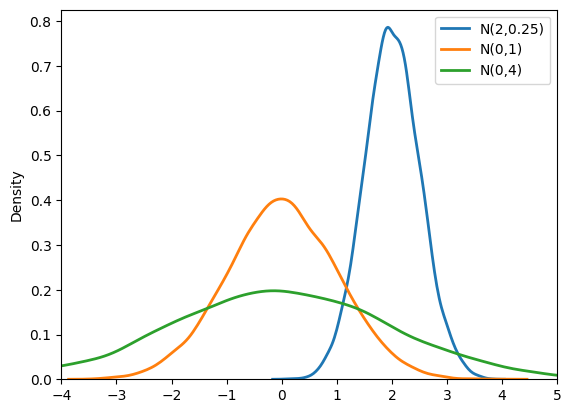

In [ ]:
N = 10000
plt.xlim([-4,5])
s = np.random.normal(loc=2, scale=0.5, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True,
             bins=50,
             kde_kws={'linewidth': 2}, label='N(2,0.25)')

s = np.random.normal(loc=0, scale=1, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True,
             bins=50,
             kde_kws={'linewidth': 2}, label='N(0,1)')

s = np.random.normal(loc=0, scale=2, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True,
             bins=50,# color = 'darkblue',
             kde_kws={'linewidth': 2}, label='N(0,4)')

plt.legend()
plt.show()

**Функция плотности распределения в многомерном случае**

Если значения случайной величины $X$ — это многомерные векторы, функция плотности сохраняет примерно тот же смысл: если $\Omega\subseteq\mathbb{R}^n$, то

$$P(X\in\Omega) = \int\limits_{\Omega}p(x)dx$$

**Многомерное нормальное распределение**

Многомерное нормальное распределение определяется также двумя параметрами: *вектором средних* $a$ и положительно определённой *ковариационной матрицей* $\Sigma$; оно имеет плотность

$$p(x) = \frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}$$

где, напомним, $x$ — вектор из $\mathbb{R}^n$. Компоненты вектора $a$ — это математические ожидания отдельных координат $X$, а на диагонали матрицы $\Sigma$ стоят их *дисперсии* (настоящие, без кавычек). Вне диагонали стоят *ковариации* компонент $X$ (пока вам достаточно понимать, что если они равны нулю, то эти компоненты независимы$^1$).

---
$^1$ Точнее сказать, некоррелированны, однако для компонент многомерного нормального распределения независимость и некоррелированность равносильны (на самом деле редкое и удачное свойство!).

**Несколько фактов**

* Под (n-1)-мерным эллипсоидом будем понимать гиперповерхность в $\mathbb{R}^n$, такую что в некоторой прямоугольной декартовой системе координат её уравнение принимает вид $\sum_{i=1}^n \frac{x_i^2}{r_i^2} = 1$. Поверхности уровня $p(x) = c$ — это эллипсоиды.

*  Пользуясь теоремой о приведении квадратичной формы к главным осям, можно показать, что функция плотности многомерного нормального распределения представляется в виде произведения одномерных нормальных плотностей при переходе в новую систему координат.
$$p(x)=\frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}\:\underset{\text{новая система координат}}{\to}\: p(x)=p(x_1)\cdot ...\cdot p(x_n)$$

    В частности, это означает, что с помощью замены координат можно добиться того, чтобы отдельные компоненты были независимы (то есть матрица ковариации $\Sigma$ диагональна).

А мы тем временем продемонстрируем это на конкретном примере, сгенерировав много точек из двумерного нормального распределения с вектором средних $(-1,3)$ и ковариационной матрицей

$$\begin{pmatrix}
1 & \frac32\\
\frac32 & 5
\end{pmatrix}$$

и нарисовав приближённо линии уровня функции плотности.

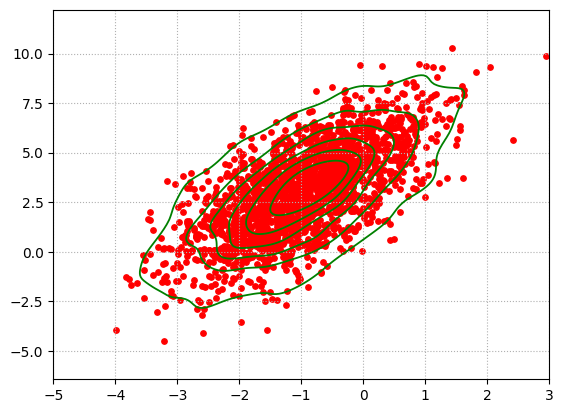

In [ ]:
import seaborn as sns
import numpy as np

N = 2000
plt.xlim([-5,3])
s = np.random.multivariate_normal(mean=np.array([-1,3]), cov=np.array([[1,1.5],[1.5,5]]), size=N)
plt.scatter(s[:,0], s[:,1], color='red', s=15)
sns.kdeplot(x=s[:, 0], y=s[:, 1],
            levels=7,
            color='g',
            fill=False,
            linewidths=1.3)
plt.grid(ls=':')

Как видите, линии уровня весьма напоминают эллипсы (только напоминают, потому что точек у нас всё-таки конечное число).

**1. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (0,0)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & -2\\
-2 & 5
\end{pmatrix}.$$

In [ ]:
N = 1000
s = np.random.multivariate_normal(mean=np.array([0,0]), cov=np.array([[1,-2],[-2,5]]), size=N)

**2. [0.25 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте на плоскости все точки $x_i$ и направления новых признаков. Убедитесь, что направления новых признаков примерно совпадают с направлениями полуосей эллипса, образованного точками.

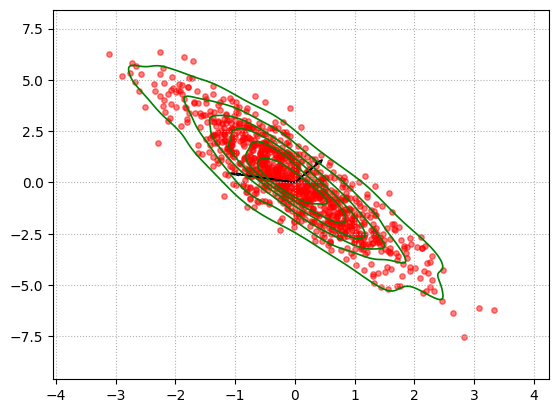

In [ ]:
U, S, VT = svd(s, full_matrices=False)
plt.scatter(s[:,0], s[:,1], color='red', s=15, alpha = 0.5)
plt.arrow(0, 0, VT[0][0], VT[1][0], head_width=0.1, head_length=0.2)
plt.arrow(0, 0, VT[0][1], VT[1][1], head_width=0.1, head_length=0.2)
sns.kdeplot(x=s[:, 0], y=s[:, 1],
            levels=7,
            color='g',
            fill=False,
            linewidths=1.2)
plt.grid(ls=':')

**3. [0.5 балла]** Приведите к главным осям матрицу ковариации (это нужно сделать без привлечения `Python`) и убедитесь, что направления этих осей тоже примерно совпадают с наблюдаемыми направлениями полуосей эллипсоида.

**Решение:**\
$\Sigma = \begin{pmatrix}
1 & -2\\
-2 & 5
\end{pmatrix}.$\
Приведем $\Sigma$ к главным осям.\
$\det(\Sigma-\lambda E)=\begin{vmatrix}1-\lambda & -2\\-2 & 5-\lambda\end{vmatrix}=(1-\lambda)(5-\lambda)-4=1-6\lambda+\lambda^{2}$.\
Собственные значения:
$\lambda_{1,2}=3\pm2\sqrt{2}$\
Собственные векторы:\
$\begin{pmatrix}-2-2\sqrt{2} & -2\\-2 & 2-2\sqrt{2}\end{pmatrix}\rightarrow\begin{pmatrix}1 & \sqrt{2}-1\\0 & 0\end{pmatrix}\\v_1=(1-\sqrt{2},1)^T$.\
$\begin{pmatrix}-2+2\sqrt{2} & -2\\-2 & 2+2\sqrt{2}\end{pmatrix}\rightarrow\begin{pmatrix}1 & -1-\sqrt{2}\\0 & 0\end{pmatrix}\\v_2=(1+\sqrt{2},1)^T$.


$v_1^{\mathsf T}v_2 = 0$, то есть эти векторы взаимно перпендикулярны.\
Нормируем их:\
$|v_1|=\sqrt{(1-\sqrt2)^2+1}=\sqrt{1-2\sqrt2+2}=\sqrt{3-2\sqrt2}\\|v_2|=\sqrt{(1+\sqrt2)^2+1}=\sqrt{1+2\sqrt2+2}=\sqrt{3+2\sqrt2}\\e_1=v_1/|v_1|, e_2=v_2/|v_2|$\
$V=\bigl[e_1e_2\bigr]$\
$\Sigma = V\Lambda V^T, \Lambda=diag(\lambda_1,\lambda_2)$\
$e_1\approx\; (-1,2.41), e_2\approx\; (1,0.41 )$ - эти векторы задают направление главных полуосей элипса, что примерно совпадают с наблюдаемыми направлениями полуосей эллипсоида.



Как Вы могли убедиться, SVD хорошо справляется со своей работой, когда данные распределены нормально, а в других случаях может давать совсем не такие информативные (или даже не адекватные) результаты.

**4. [0.25 балла]** Сгенерируйте двумерную выборку, представляющую собой два расположенных рядом (см. пример ниже) длинных и узких не пересекающихся эллипса с центрами в точках $(-1,0)$ и $(1,0)$ и с параллельными направлениями полуосей. Иными словами, постарайтесь как можно точнее воспроизвести картинку ниже.

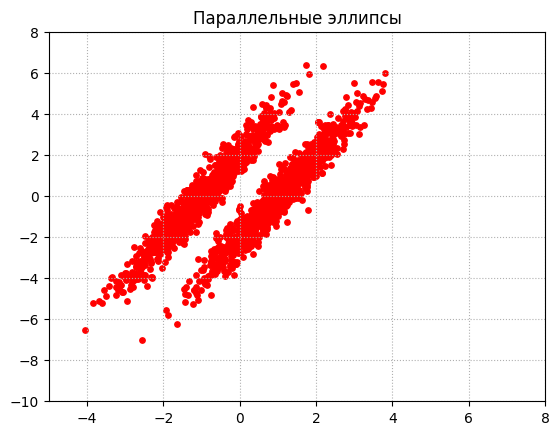

In [ ]:
N = 1000
plt.xlim([-5,8])
plt.ylim([-10,8])
X = np.random.multivariate_normal(mean=np.array([-1, 0]), cov=np.array([[1, 2],[2, 4.3]]), size=N)
Y = np.random.multivariate_normal(mean=np.array([1, 0]), cov=np.array([[1, 2],[2, 4.3]]), size=N)
plt.scatter(X[:,0], X[:,1], color='red', s=15)
plt.scatter(Y[:,0], Y[:,1], color='red', s=15)
plt.title('Параллельные эллипсы')
plt.grid(ls=':')
plt.show()

**5. [0.1 балла]** Сделайте SVD и нарисуйте направления новых признаков.

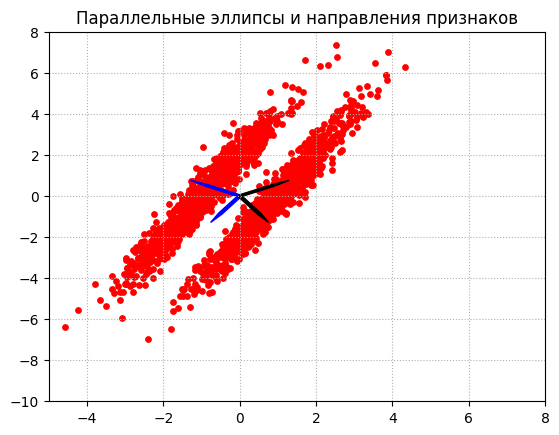

In [ ]:
N = 1000
plt.xlim([-5,8])
plt.ylim([-10,8])
X = np.random.multivariate_normal(mean=np.array([-1, 0]), cov=np.array([[1, 2],[2, 4.3]]), size=N)
Y = np.random.multivariate_normal(mean=np.array([1, 0]), cov=np.array([[1, 2],[2, 4.3]]), size=N)
plt.scatter(X[:,0], X[:,1], color='red', s=15)
plt.scatter(Y[:,0], Y[:,1], color='red', s=15)
Ux, Sx, VTx = svd(X, full_matrices=False)
Uy, Sy, VTy = svd(Y, full_matrices=False)
plt.arrow(0, 0, VTx[0][0], VTx[1][0],  color='blue', width=0.1, head_width=0.1, head_length=0.5)
plt.arrow(0, 0, VTx[0][1], VTx[1][1],  color='blue', width=0.1, head_width=0.1, head_length=0.5)

plt.arrow(0, 0, VTy[0][0], VTy[1][0], color='black', width=0.1, head_width=0.1, head_length=0.5)
plt.arrow(0, 0, VTy[0][1], VTy[1][1], color='black', width=0.1, head_width=0.1, head_length=0.5)
plt.grid(ls=':')
plt.title('Параллельные эллипсы и направления признаков')
plt.show()

Если бы мы решали задачу анализа данных, то скорее всего нас интересовал признак, который бы разделял два кластера (в данном случае два эллипса), то есть такая функция $f(x)$, для которой
$$f(x) < c,\ \mbox{если объект $x$ из первого класса}$$
$$f(x) > c,\ \mbox{если объект $x$ из второго класса}$$
для некоторого числа $c$.

**6. [0.25 балла]** Помогает ли какой-нибудь из двух предоставленных SVD признаков обнаружить эту структуру? Обязательно поясните свой ответ.

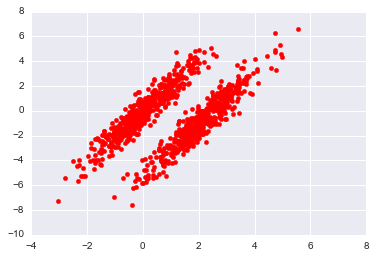

In [ ]:
# Just keep this image as a sample

**7. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (1,1)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & 0\\
0 & 4
\end{pmatrix}.$$

In [ ]:
N = 1000
X2 = np.random.multivariate_normal(mean=np.array([1, 1]), cov=np.array([[1, 0],[0, 4]]), size=N)

**8. [0.2 балла]** Очевидно, что "интересными" для этого датасета направлениями будут направления полуосей эллипса-облака точек. Глядя только на матрицу $\Sigma$, определите, что это будут за направления? Поясните свой ответ.

╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

**9. [0.1 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте все точки $x_i$ на плоскости и направления новых признаков.

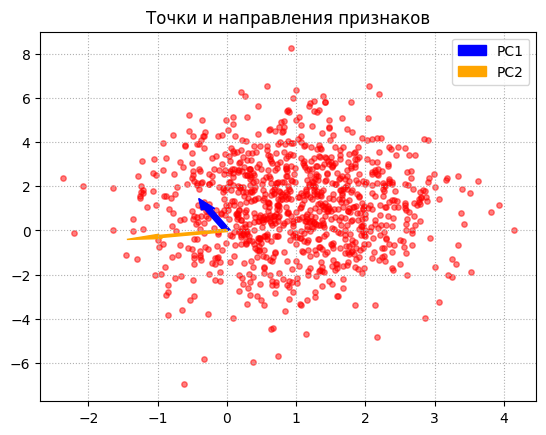

In [ ]:
N = 1000
X2 = np.random.multivariate_normal(mean=np.array([1, 1]), cov=np.array([[1, 0],[0, 4]]), size=N)
plt.scatter(X2[:,0], X2[:,1], color='red', s=15, alpha=0.5)
U2, S2, VT2 = svd(X2, full_matrices=False)
plt.arrow(0, 0, VT2[0][0], VT2[1][0], color = 'blue', width=0.1, head_width=0.2, head_length=0.5, label='PC1')
plt.arrow(0, 0, VT2[0][1], VT2[1][1], color = 'orange', width=0.1, head_width=0.2, head_length=0.5, label=f'PC2')
plt.grid(ls=':')
plt.legend()
plt.title('Точки и направления признаков')
plt.show()

**10. [0.4 балла]** Сделайте вывод: в чём проблема и как можно её исправить?

**Вывод:** Можно заметить, что PC1(синяя стрелка) идёт не строго вверх, а PC2(оранжевая стрелка) — не строго горизонтальна.
Для рассматриваемого нормального распределения главные оси эллипса должны быть параллельны осям координат. Чтобы это исправить, необходимо центрирование (нужно из каждого признака вычесть его средние значения).